In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
import math
import time
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
import seaborn as sns

# 2 Tasks:

In [2]:
# Dataset for classificatin purpose
df = pd.read_csv('WineQT.csv')
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [3]:
# Partition the dataset into train, validation, and test sets
X = df.drop(columns=['Id', 'quality'], axis='columns')
y = df['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)
print(y_test)

158     5
1081    6
291     5
538     6
367     6
       ..
66      4
328     6
67      5
231     6
966     6
Name: quality, Length: 229, dtype: int64


In [5]:
#  Normalise and standarize the data.

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# Fitting and transforming training data
X_train_normalized = scaler.fit_transform(X_train)

# Transforming validation and test data 
X_val_normalized = scaler.transform(X_val)
X_test_normalized = scaler.transform(X_test)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fitting and transforming training data
X_train_standardized = scaler.fit_transform(X_train_normalized)

# Transforming validation and test data
X_val_standardized = scaler.transform(X_val_normalized)
X_test_standardized = scaler.transform(X_test_normalized)

In [6]:
X_train_classification = np.array(X_train_standardized)
X_val_classification = np.array(X_val_standardized)
X_test_classification = np.array(X_test_standardized)
y_train_classification = np.array(y_train) 
y_test_classification = np.array(y_test)
y_val_classification = np.array(y_val)
print(y_test_classification)

[5 6 5 6 6 8 5 5 6 5 7 6 6 6 5 6 5 5 5 6 6 6 5 7 6 5 7 6 5 6 6 6 6 5 6 5 6
 7 6 5 7 5 6 5 4 5 6 6 5 6 7 5 6 7 5 7 6 4 6 5 5 6 5 6 6 6 6 5 5 5 6 5 6 6
 5 5 5 5 5 6 5 6 5 6 6 6 6 5 6 6 5 5 6 5 5 5 6 7 6 6 7 6 5 6 5 5 6 7 6 7 7
 5 5 5 6 5 5 8 6 5 5 5 5 6 5 6 6 6 6 6 5 5 7 6 5 5 5 6 5 6 7 6 6 5 7 5 5 5
 5 5 7 6 6 5 6 6 5 5 7 5 5 5 6 5 7 5 6 4 6 5 6 5 5 6 5 5 7 5 6 6 6 5 6 6 5
 4 6 5 6 4 6 6 7 6 5 6 5 7 7 6 6 6 5 5 7 7 5 5 6 6 5 6 6 6 5 6 7 5 6 6 6 5
 5 5 4 6 5 6 6]


In [7]:
# Dataset for regression purpose. 
df = pd.read_csv('HousingData.csv')
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


CRIM: Per capita crime rate by town <br>
ZN: Proportion of residential land zoned for lots over 25,000 sq. ft <br>
INDUS: Proportion of non-retail business acres per town <br>
CHAS: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise) <br> 
NOX: Nitric oxide concentration (parts per 10 million) <br> 
RM: Average number of rooms per dwelling <br>
AGE: Proportion of owner-occupied units built prior to 1940 <br> 
DIS: Weighted distances to five Boston employment centers <br> 
RAD: Index of accessibility to radial highways <br> 
TAX: Full-value property tax rate per 10,000 Dollars <br> 
PTRATIO: Pupil-teacher ratio by town <br>
B: 1000(Bk — 0.63)², where Bk is the proportion of [people of African American descent] by town. <br> 
LSTAT: Percentage of lower status of the population <br> 
MEDV: Median value of owner-occupied homes in $1000s <br> 

In [8]:

# Partition the dataset into train, validation, and test sets.
X = df.drop('MEDV', axis=1)
y = df['MEDV']

imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)
y_imputed = imputer.fit_transform(y.values.reshape(-1, 1))

X = pd.DataFrame(X_imputed, columns=X.columns)
y = pd.Series(y_imputed.flatten())

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.3, random_state = 42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = 42)


# Normalise and standarize the data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# Fitting and transforming training data
X_train_normalized = scaler.fit_transform(X_train)

# Transforming validation and test data 
X_val_normalized = scaler.transform(X_val)
X_test_normalized = scaler.transform(X_test)


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fitting and transforming training data
X_train_standardized = scaler.fit_transform(X_train_normalized)

# Transforming validation and test data
X_val_standardized = scaler.transform(X_val_normalized)
X_test_standardized = scaler.transform(X_test_normalized)

X_train = X_train_standardized
X_val = X_val_standardized
X_test = X_test_standardized

In [9]:
X_train_regression = X_train_standardized
X_val_regression = X_val_standardized
X_test_regression = X_test_standardized
y_train_regression = y_train 
y_test_regression = y_test 
y_val_regression = y_val

# 3 Ensemble Learning

# 3.1 Pre-Requisite

In [10]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV

'''
Function that return the best parameters for the List 1 models for a given dataset. 
Input: Dataset 
Output: Best Models of List 1 Models. 
'''

# ==================================== Decision Trees ============================================
# For classification:
classifier = DecisionTreeClassifier()
param_grid = {
    'max_depth': [2, 4, 6, 8],  # You can tune the depth
    'min_samples_split': [2, 10, 20],  # You can tune the minimum samples to split
}
clf = GridSearchCV(classifier, param_grid, cv=4)
clf.fit(X_train_classification, y_train_classification)
best_classifier = clf.best_estimator_

# For regression:
regressor = DecisionTreeRegressor()
param_grid = {
    'max_depth': [2, 4, 6, 8],  # You can tune the depth
    'min_samples_split': [2, 10, 20],  # You can tune the minimum samples to split
}
reg = GridSearchCV(regressor, param_grid, cv=4)
reg.fit(X_train_regression, y_train_regression)
best_regressor = reg.best_estimator_

# ================================= Logistic and Linear Regression =================================
logistic_classifier = LogisticRegression(max_iter=10000)
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],  # You can tune the regularization parameter
}
logistic_clf = GridSearchCV(logistic_classifier, param_grid, cv=4)
logistic_clf.fit(X_train_classification, y_train_classification)
best_logistic_classifier = logistic_clf.best_estimator_


linear_regressor = LinearRegression() # No hyperparameters to tune
linear_reg = linear_regressor.fit(X_train_regression, y_train_regression)

# =========================== Multi Layer Perceptron (MLP) ==========================================
mlp_classifier = MLPClassifier(max_iter=3000)
param_grid = {
    'hidden_layer_sizes': [(50, 50), (100, 50), (100, 100)],  # Tune the architecture
    'alpha': [0.0001, 0.001, 0.01],  # Regularization parameter
}
mlp_clf = GridSearchCV(mlp_classifier, param_grid, cv=4)
mlp_clf.fit(X_train_classification, y_train_classification)
best_mlp_classifier = mlp_clf.best_estimator_


mlp_regressor = MLPRegressor(max_iter=3000)
param_grid = {
    'hidden_layer_sizes': [(50, 50), (100, 50), (100, 100)],  # Tune the architecture
    'alpha': [0.0001, 0.001, 0.01],  # Regularization parameter
}
mlp_reg = GridSearchCV(mlp_regressor, param_grid, cv=4)
mlp_reg.fit(X_train_regression, y_train_regression)
best_mlp_regressor = mlp_reg.best_estimator_


# 3.2 Bagging

### Classification

In [11]:
from scipy.stats import mode
from sklearn.metrics import accuracy_score

# Define a function to find the mode along axis 1
def mode_along_axis0(col):
    result = mode(col)
    return result.mode

def mode_along_axis1(row):
    result = mode(row)
    return result.mode
    
def bagging_ensemble_classification(X_train, y_train, X_val, y_val, base_estimator, n_estimators, fraction, bootstrap, voting):
    
    # List to store the base estimator models
    base_models = [base_estimator for _ in range(n_estimators)]

    # Finding total number of samples. 
    n_samples = int(fraction * len(X_train))

    # List to store the predictions
    predictions = []
    class_probability = []

    for model in base_models:
        if bootstrap:
            # Sample with replacement
            indices = np.random.choice(range(len(X_train)), size=n_samples, replace=True)
        else:
            # Sample without replacement
            indices = np.random.choice(range(len(X_train)), size=n_samples, replace=False)
        
        y_train = np.ravel(y_train)
        model.fit(X_train[indices], y_train[indices])
        y_pred_model = model.predict(X_val)
        # Store the predictions
        predictions.append(y_pred_model)
        class_probability.append(model.predict_proba(X_val))

    # voting mechanism
    if voting == "hard":
        predictions = np.vstack(predictions)
        # print(predictions)
        # Hard voting: Count votes and choose the majority class
        y_pred = np.apply_along_axis(mode_along_axis0, axis=0, arr=predictions)
        
    elif voting == "soft":
        # Soft voting: Weighted average of predictions
        # class_probability = np.array(class_probability)
        # predictions = np.mean(class_probability, axis=0)
        # print(np.mean(class_probability, axis=0))
        y_pred = (np.argmax(np.mean(np.array(class_probability), axis=0), axis=1)+3)
        y_pred = np.mean(predictions, axis=1)

    # print(y_pred)
    accuracy = accuracy_score(y_val, y_pred)
    # print(accuracy)
    return accuracy

In [36]:
# Example Use
base_estimator_model = best_classifier
n_estimators = 5
fraction = 0.5 
bootstrap = False 
voting_mechanism = 'hard' 

bagging_ensemble_classification(X_train_classification, y_train_classification, X_val_classification, y_val_classification, base_estimator_model, n_estimators, fraction, bootstrap, voting_mechanism)

base_models = [best_classifier, best_logistic_classifier, best_mlp_classifier]
name = ["Decision Tree", "Logistic Regression", "MLP"]
fraction = [0.15, 0.25, 0.5, 0.75, 1.0]
bootstrap_bool = [True, False]
voting = ['hard', 'soft']
best = 0
hyperpara = []
for i, base in enumerate(base_models):
    for frac in fraction:
        for bootstrap in bootstrap_bool:
            for vote in voting:
                print("Base Estimator Model: ", name[i], "Fraction: ", frac, "Bootstrap: ", bootstrap, "Voting: ", vote)
                acc = bagging_ensemble_classification(X_train_classification, y_train_classification, X_val_classification, y_val_classification, base, n_estimators, frac, bootstrap, voting_mechanism)
                print(acc)
                if(acc>best):
                    best = acc
                hyperpara = [name[i], frac, bootstrap, vote]

print("Best Accuracy: ", best)
print("Best Hyperparameters: ", hyperpara)

Base Estimator Model:  Decision Tree Fraction:  0.15 Bootstrap:  True Voting:  hard
0.537117903930131
Base Estimator Model:  Decision Tree Fraction:  0.15 Bootstrap:  True Voting:  soft
0.5895196506550219
Base Estimator Model:  Decision Tree Fraction:  0.15 Bootstrap:  False Voting:  hard
0.5502183406113537
Base Estimator Model:  Decision Tree Fraction:  0.15 Bootstrap:  False Voting:  soft
0.537117903930131
Base Estimator Model:  Decision Tree Fraction:  0.25 Bootstrap:  True Voting:  hard
0.5633187772925764
Base Estimator Model:  Decision Tree Fraction:  0.25 Bootstrap:  True Voting:  soft
0.5720524017467249
Base Estimator Model:  Decision Tree Fraction:  0.25 Bootstrap:  False Voting:  hard
0.5633187772925764
Base Estimator Model:  Decision Tree Fraction:  0.25 Bootstrap:  False Voting:  soft
0.5676855895196506
Base Estimator Model:  Decision Tree Fraction:  0.5 Bootstrap:  True Voting:  hard
0.5545851528384279
Base Estimator Model:  Decision Tree Fraction:  0.5 Bootstrap:  True Vot

### Regression

In [54]:
from scipy.stats import mode
from sklearn.metrics import accuracy_score

def bagging_ensemble_regression(X_train, y_train, X_val, y_val, base_estimator, n_estimators, fraction, bootstrap, voting):

    # List to store the base estimator models
    base_models = [base_estimator for _ in range(n_estimators)]

    # Finding total number of samples. 
    n_samples = int(fraction * len(X_train))

    # List to store the predictions
    predictions = []
    weights = []
    
    for model in base_models:
        if bootstrap:
            # Sample with replacement
            indices = np.random.choice(range(len(X_train)), size=n_samples, replace=True)
        else:
            # Sample without replacement
            indices = np.random.choice(range(len(X_train)), size=n_samples, replace=False)
        
        y_train = np.ravel(y_train)
        model.fit(X_train[indices], y_train[indices])
        y_pred_model = model.predict(X_val)
        # Store the predictions
        predictions.append(y_pred_model)
        # class_probability.append(model.predict_proba(X_val))
        weights.append(r2_score(y_val, y_pred_model))

    predictions = np.vstack(predictions)
    # print(predictions)
    
    # voting mechanism
    if voting == "hard":
        
        # Hard voting: Count votes and choose the majority class
        y_pred = np.mean(predictions, axis=0)
        
    elif voting == "soft":
        # Soft voting: Weighted average of predictions
        weights = np.array(weights)
        y_pred = np.dot(weights, prediction)/np.sum(weights)
        

    # print(y_pred)
    r2 = r2_score(y_val, y_pred)
    # print(r2)
    return r2

# Example Use
base_estimator_model = best_regressor
n_estimators = 5
fraction = 0.5 
bootstrap = False 
voting_mechanism = 'hard' 

bagging_ensemble_regression(X_train_regression, y_train_regression, X_val_regression, y_val_regression, base_estimator_model, n_estimators, fraction, bootstrap, voting_mechanism)

base_models = [best_regressor, linear_reg, best_mlp_regressor]
name = ["Decision Tree", "Linear Regression", "MLP"]
fraction = [0.15, 0.25, 0.5, 0.75, 1.0]
bootstrap_bool = [True, False]
voting = ['hard', 'soft']
best = 0
hyperpara = []
for i, base in enumerate(base_models):
    for frac in fraction:
        for bootstrap in bootstrap_bool:
            for vote in voting:
                print("Base Estimator Model: ", name[i], "Fraction: ", frac, "Bootstrap: ", bootstrap, "Voting: ", vote)
                r2 = bagging_ensemble_regression(X_train_classification, y_train_classification, X_val_classification, y_val_classification, base, n_estimators, frac, bootstrap, voting_mechanism)
                print(r2)
                if(r2>best):
                    best = r2
                hyperpara = [name[i], frac, bootstrap, vote]

print("Best R2 Score: ", best)
print("Best Hyperparameters: ", hyperpara)


Base Estimator Model:  Decision Tree Fraction:  0.15 Bootstrap:  True Voting:  hard
0.3140591144793441
Base Estimator Model:  Decision Tree Fraction:  0.15 Bootstrap:  True Voting:  soft
0.31465085388150715
Base Estimator Model:  Decision Tree Fraction:  0.15 Bootstrap:  False Voting:  hard
0.3602931549051803
Base Estimator Model:  Decision Tree Fraction:  0.15 Bootstrap:  False Voting:  soft
0.32964841492417873
Base Estimator Model:  Decision Tree Fraction:  0.25 Bootstrap:  True Voting:  hard
0.30967927929812755
Base Estimator Model:  Decision Tree Fraction:  0.25 Bootstrap:  True Voting:  soft
0.34188193361278096
Base Estimator Model:  Decision Tree Fraction:  0.25 Bootstrap:  False Voting:  hard
0.32271481116895606
Base Estimator Model:  Decision Tree Fraction:  0.25 Bootstrap:  False Voting:  soft
0.2868168868555656
Base Estimator Model:  Decision Tree Fraction:  0.5 Bootstrap:  True Voting:  hard
0.31936535390560283
Base Estimator Model:  Decision Tree Fraction:  0.5 Bootstrap:  

### Heatmap

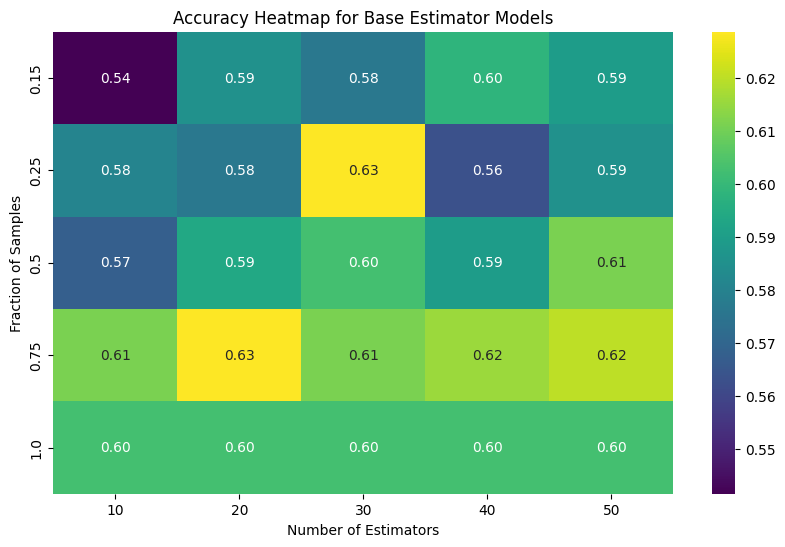

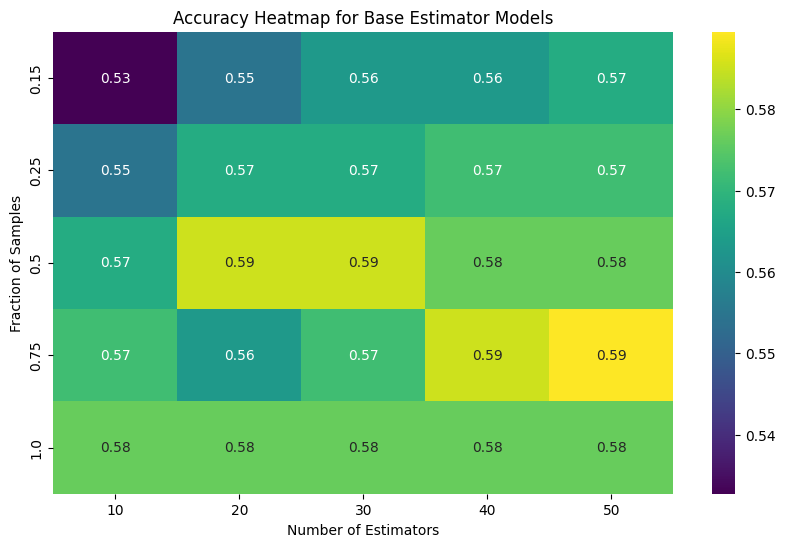

In [ ]:
# Classification 

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

base_models = [best_classifier, best_logistic_classifier, best_mlp_classifier]
fraction_samples = [0.15, 0.25, 0.5, 0.75, 1.0]
num_estimators = [10, 20, 30, 40, 50]  

for base in base_models:
    acc_models = []
    for frac in fraction_samples:
        acc_list = []
        for n_estimators in num_estimators:
            acc_list.append(bagging_ensemble_classification(X_train_classification, y_train_classification, X_val_classification, y_val_classification, base, n_estimators, frac, False, 'hard'))
        acc_models.append(acc_list)
    acc_models = np.array(acc_models)
    acc_models = np.vstack(acc_models)

    plt.figure(figsize=(10, 6))
    sns.heatmap(acc_models, annot=True, fmt=".2f", cmap="viridis",
                xticklabels=num_estimators, yticklabels=fraction_samples)
    
    plt.xlabel("Number of Estimators")
    plt.ylabel("Fraction of Samples")
    plt.title("Accuracy Heatmap for Base Estimator Models")
    plt.show()


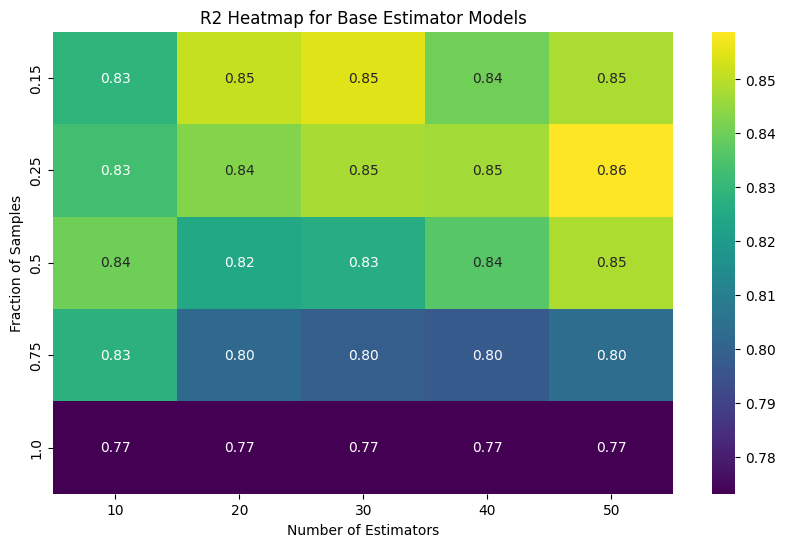

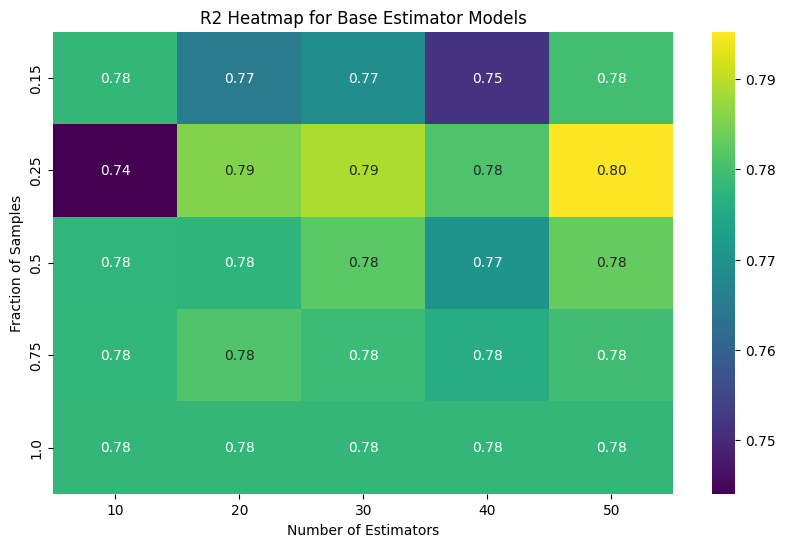

In [ ]:
# Regression

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

base_models = [best_regressor, linear_reg, best_mlp_regressor]
fraction_samples = [0.15, 0.25, 0.5, 0.75, 1.0]
num_estimators = [10, 20, 30, 40, 50]  

for base in base_models:
    r2_models = []
    for frac in fraction_samples:
        r2_list = []
        for n_estimators in num_estimators:
            r2_list.append(bagging_ensemble_regression(X_train_regression, y_train_regression, X_val_regression, y_val_regression, base, n_estimators, frac, False, 'hard'))
        r2_models.append(r2_list)
    r2_models = np.array(r2_models)
    r2_models = np.vstack(r2_models)

    plt.figure(figsize=(10, 6))
    sns.heatmap(r2_models, annot=True, fmt=".2f", cmap="viridis",
                xticklabels=num_estimators, yticklabels=fraction_samples)
    
    plt.xlabel("Number of Estimators")
    plt.ylabel("Fraction of Samples")
    plt.title("R2 Heatmap for Base Estimator Models")
    plt.show()


### Histogram

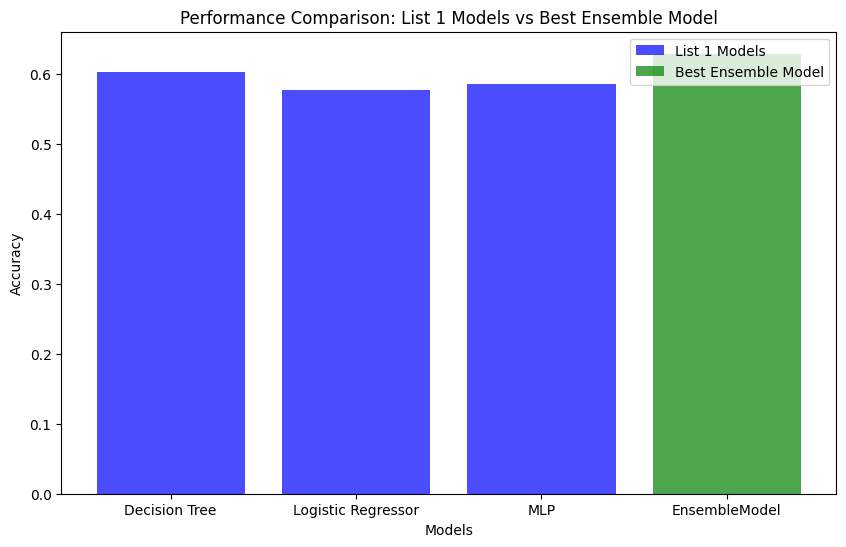

In [31]:
# Classification 

X_train, y_train, X_val, y_val = X_train_classification, y_train_classification, X_val_classification, y_val_classification

list1_model_names = ["Decision Tree", "Logistic Regressor", "MLP"]
list1_models = [best_classifier, best_logistic_classifier, best_mlp_classifier]
list1_model_accuracies = []

for model in list1_models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    list1_model_accuracies.append(acc)
    
best_ensemble_model_name = 'EnsembleModel'
best_ensemble_model_accuracy = 0.62882096069869

bar_positions = np.arange(len(list1_model_names)) 

plt.figure(figsize=(10, 6))
plt.bar(bar_positions, list1_model_accuracies, label='List 1 Models', color='blue', alpha=0.7)
plt.bar(len(list1_model_names), best_ensemble_model_accuracy, label='Best Ensemble Model', color='green', alpha=0.7)

plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Performance Comparison: List 1 Models vs Best Ensemble Model')
plt.xticks(np.append(bar_positions, len(list1_model_names)), list1_model_names + [best_ensemble_model_name])
plt.legend()
plt.show()


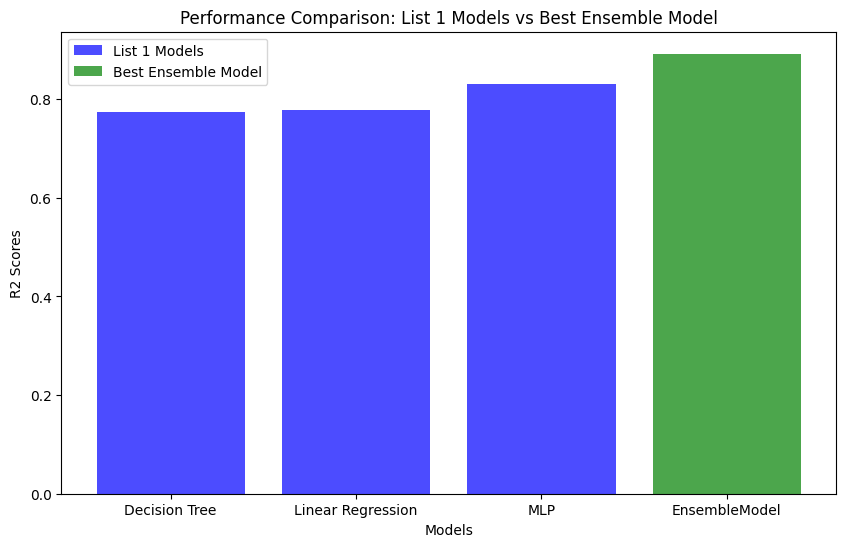

In [32]:
# Regression

X_train, y_train, X_val, y_val = X_train_regression, y_train_regression, X_val_regression, y_val_regression

list1_model_names = ["Decision Tree", "Linear Regression", "MLP"]
list1_models = [best_regressor, linear_reg, best_mlp_regressor]
list1_model_r2 = []

for model in list1_models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    r2 = r2_score(y_val, y_pred)
    list1_model_r2.append(r2)
    
best_ensemble_model_name = 'EnsembleModel'
best_ensemble_model_r2 = 0.8923673903022715

bar_positions = np.arange(len(list1_model_names)) 

plt.figure(figsize=(10, 6))
plt.bar(bar_positions, list1_model_r2, label='List 1 Models', color='blue', alpha=0.7)
plt.bar(len(list1_model_names), best_ensemble_model_r2, label='Best Ensemble Model', color='green', alpha=0.7)

plt.xlabel('Models')
plt.ylabel('R2 Scores')
plt.title('Performance Comparison: List 1 Models vs Best Ensemble Model')
plt.xticks(np.append(bar_positions, len(list1_model_names)), list1_model_names + [best_ensemble_model_name])
plt.legend()
plt.show()


# 3.3 Stacking

In [17]:
# Source: https://medium.com/@stevenyu530_73989/stacking-and-blending-intuitive-explanation-of-advanced-ensemble-methods-46b295da413c

def Stacking(model,train,y,test,n_fold):
    folds=StratifiedKFold(n_splits=n_fold,random_state=1, shuffle=True)
    # test_pred=np.empty((test.shape[0],1),float)
    test_pred=np.empty((0,1),float)
    train_pred=np.empty((0,1),float)
  
    for train_indices,val_indices in folds.split(train,y.values):
        x_train,x_val=train.iloc[train_indices],train.iloc[val_indices]
        y_train,y_val=y.iloc[train_indices],y.iloc[val_indices]
        model.fit(X=x_train,y=y_train)
        train_pred=np.append(train_pred,model.predict(x_val))
    test_pred=np.append(test_pred,model.predict(test))
    
    return test_pred.reshape(-1,1),train_pred

In [43]:
from sklearn.metrics import accuracy_score

def ensemble(type, level0estimator, num_level0estimators, level1estimator, methodology):
    if type == "classification":
        X_train = pd.DataFrame(X_train_classification)
        X_val = pd.DataFrame(X_val_classification)
        X_test = pd.DataFrame(X_test_classification) 
        y_train = pd.DataFrame(y_train_classification)
        y_test = pd.DataFrame(y_test_classification)
        y_val = pd.DataFrame(y_val_classification)
    else: 
        X_train = pd.DataFrame(X_train_regression) 
        X_val = pd.DataFrame(X_val_regression)
        X_test = pd.DataFrame(X_test_regression) 
        y_train = pd.DataFrame(y_train_regression)
        y_test = pd.DataFrame(y_test_regression)
        y_val = pd.DataFrame(y_val_regression)
    # print(y_test.shape)
    if methodology == "stacking":
        # Empty list to store dataframes 
        train_dataframes = []
        test_dataframes = []
        # true_test_dataframes = []
        for itr in range (0, num_level0estimators):
            # Initialise the base models
            model = level0estimator
    
            # Train base models and create new featurs
            test_pred ,train_pred = Stacking(model = model, n_fold = 4, train = X_train, test = X_test, y = y_train)
            # print(test_pred.shape)
            # Convert into dataframe for later use
            train_pred = pd.DataFrame(train_pred)
            train_dataframes.append(train_pred)
            
            test_pred = pd.DataFrame(test_pred)
            test_dataframes.append(test_pred)
            # true_test_dataframes.append(y_test)
            
        df = pd.concat(train_dataframes, ignore_index = True, axis = 1)
        df_test = pd.concat(test_dataframes, ignore_index = True, axis = 1)
        # df_true_test = pd.concat(true_test_dataframes, ignore_index = True, axis = 1)

        model = level1estimator
        y_train = y_train.to_numpy()
        y_train = y_train.ravel()
        model.fit(df,y_train)
        df_test = df_test.to_numpy()
        y_test = y_test.to_numpy()
        y_pred = model.predict(df_test)
        y_pred = y_pred.ravel()
        y_test = y_test.ravel()
        # model.score(y_pred, y_test)
        if type=="classification":
            accuracy = accuracy_score(y_test, y_pred)
            # print(accuracy)
            return accuracy
        else: 
            r2 = r2_score(y_test, y_pred)
            return r2

    else: 
        df_holdout = pd.DataFrame(X_val)
        df_test=pd.DataFrame(X_test)
        for itr in range (0, num_level0estimators):
            model_1 = level0estimator
            model_1.fit(X_train, y_train)
            holdout_pred_1=model_1.predict(X_val)
            test_pred_1=model_1.predict(X_test)
            holdout_pred_1=pd.DataFrame(holdout_pred_1)
            pd.concat([df_holdout, holdout_pred_1], axis=1)
            test_pred_1=pd.DataFrame(test_pred_1)
            pd.concat([df_test, test_pred_1],axis=1)
        
        # model_2 = KNeighborsClassifier()
        # model_2.fit(x_train,y_train)
        # holdout_pred_2=model_2.predict(x_val)
        # test_pred_2=model_2.predict(x_test)
        # holdout_pred_2=pd.DataFrame(holdout_pred_2)
        # test_pred_2=pd.DataFrame(test_pred_2)

        # df_holdout=pd.concat([x_val, holdout_pred_1,holdout_pred_2],axis=1)
        # df_test=pd.concat([x_test, test_pred_1,test_pred_2],axis=1)
        
        model = LogisticRegression()
        y_val = y_val.to_numpy()
        y_val=y_val.ravel()
        model.fit(df_holdout,y_val)
        model.score(df_test,y_test)
        y_pred=model.predict(df_test)
        y_pred = np.ravel(y_pred)
        if type=="classification":
            accuracy = accuracy_score(y_test, y_pred)
            # print(accuracy)
            return accuracy
        else: 
            r2 = r2_score(y_test, y_pred)
            return r2

In [44]:
ensemble("classification", best_classifier, 4, best_logistic_classifier, "blending")

0.5807860262008734

In [45]:
# Number of estimators in Level 0 can be chosen. 
num_l0_estimators = 4
level0=["Decision Tree", "Logistic Regression", "MLP"]
level1=["Decision Tree", "Logistic Regression"]
level0estimators_classification = [best_classifier, best_logistic_classifier, best_mlp_classifier]
level1estimators_classification = [best_classifier, best_logistic_classifier] 
methods = ["stacking", "blending"]

best = 0
hyper_c = []
for ite1, l0 in enumerate(level0estimators_classification): 
    for ite2, l1 in enumerate(level1estimators_classification): 
        for method in methods: 
            print("Level 0: ", level0[ite1], "Level 1: ", level1[ite2], "Method: ", method)
            acc=ensemble("classification", l0, num_l0_estimators, l1, method)
            print("Accuracy: ", acc)
            if(acc>best):
                best=acc
                hyper_c=[level0[ite1], level1[ite2], method]

print("Best Accuracy: ", best)
print("Hyperparameters", hyper_c)

level0=["Decision Tree", "Linear Regression", "MLP"]
level1=["Decision Tree", "Linear Regression"]
level0estimators_regression = [best_regressor, linear_reg, best_mlp_regressor]
level1estimators_regression = [best_regressor, linear_reg]
methods = ["stacking", "blending"]

# best=0
# hyper_r=[]
# for l0 in level0estimators_regression: 
#     for l1 in level1estimators_regression: 
#         for method in methods: 
#             print("Level 0: ", level0[ite1], "Level 1: ", level1[ite2], "Method: ", method)
#             r2=ensemble("regression", l0, num_l0_estimators, l1, method)
#             print("R2 Score: ", r2)
#             if(r2>best):
#                 best=r2
#                 hyper_r=[level0[ite1], level1[ite2], method]

# print("Best R2 Score: ", best)
# print("Hyperparameters", hyper_r)

Level 0:  Decision Tree Level 1:  Decision Tree Method:  stacking
Accuracy:  0.5851528384279476
Level 0:  Decision Tree Level 1:  Decision Tree Method:  blending
Accuracy:  0.5807860262008734
Level 0:  Decision Tree Level 1:  Logistic Regression Method:  stacking
Accuracy:  0.43231441048034935
Level 0:  Decision Tree Level 1:  Logistic Regression Method:  blending
Accuracy:  0.5807860262008734
Level 0:  Logistic Regression Level 1:  Decision Tree Method:  stacking


C:\Users\BPATR\OneDrive\Desktop\smai_assgn\assgn\Lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\BPATR\OneDrive\Desktop\smai_assgn\assgn\Lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\BPATR\OneDrive\Desktop\smai_assgn\assgn\Lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\BPATR\OneDrive\Desktop\smai_assgn\assgn\Lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A colu

Accuracy:  0.4279475982532751
Level 0:  Logistic Regression Level 1:  Decision Tree Method:  blending
Accuracy:  0.5807860262008734
Level 0:  Logistic Regression Level 1:  Logistic Regression Method:  stacking


C:\Users\BPATR\OneDrive\Desktop\smai_assgn\assgn\Lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\BPATR\OneDrive\Desktop\smai_assgn\assgn\Lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\BPATR\OneDrive\Desktop\smai_assgn\assgn\Lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\BPATR\OneDrive\Desktop\smai_assgn\assgn\Lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A colu

Accuracy:  0.4279475982532751
Level 0:  Logistic Regression Level 1:  Logistic Regression Method:  blending
Accuracy:  0.5807860262008734
Level 0:  MLP Level 1:  Decision Tree Method:  stacking


...

C:\Users\BPATR\OneDrive\Desktop\smai_assgn\assgn\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1102: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\BPATR\OneDrive\Desktop\smai_assgn\assgn\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1102: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\BPATR\OneDrive\Desktop\smai_assgn\assgn\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1102: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\BPATR\OneDrive\Desktop\smai_assgn\assgn\Lib\site-packages\

Accuracy:  0.43231441048034935
Level 0:  MLP Level 1:  Logistic Regression Method:  blending


C:\Users\BPATR\OneDrive\Desktop\smai_assgn\assgn\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1102: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\BPATR\OneDrive\Desktop\smai_assgn\assgn\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1102: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\BPATR\OneDrive\Desktop\smai_assgn\assgn\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1102: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\BPATR\OneDrive\Desktop\smai_assgn\assgn\Lib\site-packages\

Accuracy:  0.5807860262008734
Best Accuracy:  0.5851528384279476
Hyperparameters ['Decision Tree', 'Decision Tree', 'stacking']
Level 0:  MLP Level 1:  Linear Regression Method:  stacking


ValueError: Supported target types are: ('binary', 'multiclass'). Got 'continuous' instead.

# 4 Random Forest vs Boosted Trees

## Random Forest Classifier and Regressor

In [46]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split

# Function for bootstrap sampling
def bootstrap_sample(X, y):
    indices = np.random.choice(len(y), len(y), replace=True)
    y_hat = np.ravel(y)
    return X[indices], y_hat[indices]

# Random Forest Classifier
class RandomForestClassifier:
    def __init__(self, n_estimators=100, max_features=None):
        self.n_estimators = n_estimators
        self.max_features = max_features
        self.base_models = [DecisionTreeClassifier(max_depth=None, max_features=max_features) for _ in range(n_estimators)]

    def fit(self, X, y):
        for i in range(self.n_estimators):
            X_sample, y_sample = bootstrap_sample(X, y)
            self.base_models[i].fit(X_sample, y_sample)

    def predict(self, X):
        predictions = np.array([model.predict(X) for model in self.base_models])
        return np.round(np.mean(predictions, axis=0))

# Random Forest Regressor
class RandomForestRegressor:
    def __init__(self, n_estimators=100, max_features=None):
        self.n_estimators = n_estimators
        self.max_features = max_features
        self.base_models = [DecisionTreeRegressor(max_depth=None, max_features=max_features) for _ in range(n_estimators)]

    def fit(self, X, y):
        for i in range(self.n_estimators):
            X_sample, y_sample = bootstrap_sample(X, y)
            self.base_models[i].fit(X_sample, y_sample)

    def predict(self, X):
        predictions = np.array([model.predict(X) for model in self.base_models])
        return np.mean(predictions, axis=0)

# Example usage with synthetic data
np.random.seed(42)
X_classification = np.random.rand(100, 5)
y_classification = (X_classification[:, 0] + X_classification[:, 1] > 1.0).astype(int)

X_regression = np.random.rand(100, 5)
y_regression = X_regression[:, 0] + 2 * X_regression[:, 1] + np.random.normal(0, 0.1, 100)

# Split the data
# X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(X_classification, y_classification, test_size=0.2, random_state=42)
# X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_regression, y_regression, test_size=0.2, random_state=42)

# Split the data
# X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(X_classification, y_classification, test_size=0.2, random_state=42)
X_class_train, X_class_test, y_class_train, y_class_test = X_train_classification, X_test_classification, y_train_classification, y_test_classification
y_class_train = np.where(y_class_train > 5, 1, 0)
y_class_test = np.where(y_class_test > 5, 1, 0)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = X_train_regression, X_test_regression, y_train_regression, y_test_regression
# train_test_split(X_regression, y_regression, test_size=0.2, random_state=42)


# Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, max_features='sqrt')
rf_classifier.fit(X_class_train, y_class_train)
y_class_pred = rf_classifier.predict(X_class_test)

# Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, max_features='sqrt')
rf_regressor.fit(X_reg_train, y_reg_train)
y_reg_pred = rf_regressor.predict(X_reg_test)

# Evaluate models
accuracy = accuracy_score(y_class_test, y_class_pred)
mse = mean_squared_error(y_reg_test, y_reg_pred)

print(f"Random Forest Classifier Accuracy: {accuracy}")
print(f"Random Forest Regressor Mean Squared Error: {mse}")


Random Forest Classifier Accuracy: 0.759825327510917
Random Forest Regressor Mean Squared Error: 16.53210442105263


## Decision Trees + AdaBoost

### Classification

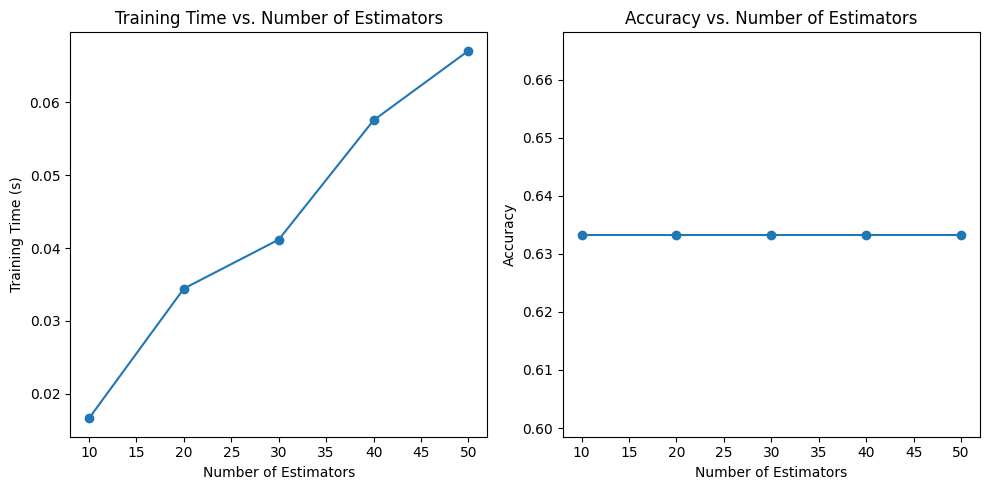

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Load Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# AdaBoost Classifier
class AdaBoostClassifier:
    def __init__(self, n_estimators=50):
        self.n_estimators = n_estimators
        self.alphas = []
        self.models = []

    def fit(self, X, y):
        n_samples, _ = X.shape
        weights = np.ones(n_samples) / n_samples  # Initialize weights uniformly

        for _ in range(self.n_estimators):
            tree = DecisionTreeClassifier(max_depth=1)
            tree.fit(X, y, sample_weight=weights)
            predictions = tree.predict(X)

            epsilon = np.sum(weights * (predictions != y)) / np.sum(weights)
            alpha = 0.5 * np.log((1 - epsilon) / epsilon)
            self.alphas.append(alpha)

            weights *= np.exp(-alpha * y * predictions)
            weights /= np.sum(weights)

            self.models.append(tree)

    def predict(self, X):
        predictions = np.array([model.predict(X) for model in self.models])
        weighted_votes = np.dot(self.alphas, predictions)
        return np.sign(weighted_votes)

# Experiment with the number of estimators
estimator_range = [10, 20, 30, 40, 50]
training_times = []
accuracies = []

for n_estimators in estimator_range:
    start_time = time.time()

    ada_boost = AdaBoostClassifier(n_estimators=n_estimators)
    ada_boost.fit(X_train, y_train)
    predictions = ada_boost.predict(X_test)

    end_time = time.time()
    elapsed_time = end_time - start_time
    accuracy = np.sum(predictions == y_test) / len(y_test)

    training_times.append(elapsed_time)
    accuracies.append(accuracy)

# Plot training times and accuracies
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(estimator_range, training_times, marker='o')
plt.title('Training Time vs. Number of Estimators')
plt.xlabel('Number of Estimators')
plt.ylabel('Training Time (s)')

plt.subplot(1, 2, 2)
plt.plot(estimator_range, accuracies, marker='o')
plt.title('Accuracy vs. Number of Estimators')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()


Accuracy: 55.46%


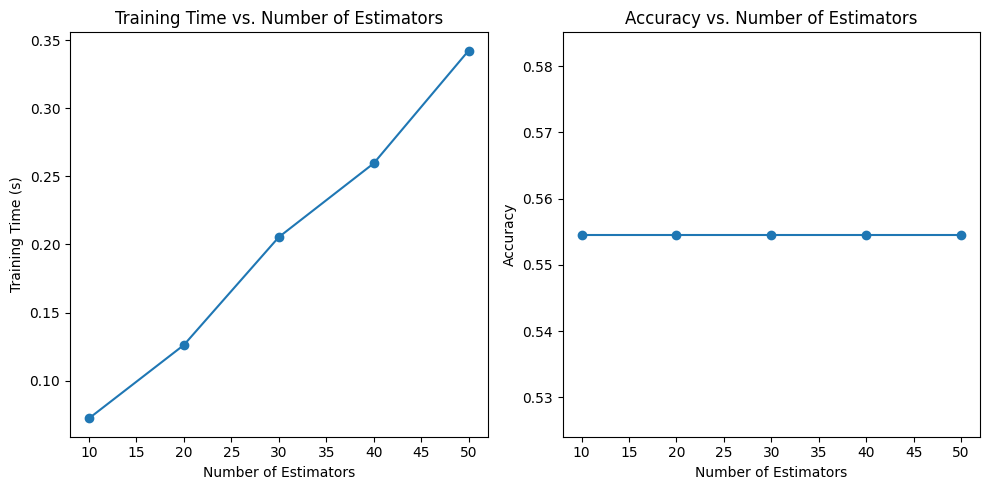

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = X_train_classification, X_test_classification, y_train_classification, y_test_classification
y_train = np.where(y_train > 5, 1, 0)
y_test = np.where(y_test > 5, 1, 0)
# print(y_train)

# Discrete AdaBoost Classifier
class AdaBoostClassifier:
    def __init__(self, n_estimators=50):
        self.n_estimators = n_estimators
        self.models = []
        self.alphas = []

    def fit(self, X, y):
        n_samples, _ = X.shape
        weights = np.ones(n_samples) / n_samples

        for _ in range(self.n_estimators):
            weak_learner = DecisionTreeClassifier(max_depth=3)
            weak_learner.fit(X, y, sample_weight=weights)
            predictions = weak_learner.predict(X)

            epsilon = np.sum(weights * (predictions != y)) / np.sum(weights)
            alpha = np.log((1 - epsilon) / epsilon)   # 0,5
            self.alphas.append(alpha)

            weights *= np.exp(alpha * (y!=predictions)) # weights *= np.exp(-alpha * y * predictions)
            weights /= np.sum(weights)

            self.models.append(weak_learner)

    def predict(self, X):
        predictions = np.array([model.predict(X) for model in self.models])
        weighted_votes = np.dot(self.alphas, predictions)
        return np.sign(weighted_votes)

# Train Discrete AdaBoost Classifier
ada_boost_classifier = AdaBoostClassifier(n_estimators=50)
ada_boost_classifier.fit(X_train, y_train)

# Make predictions on test set
predictions = ada_boost_classifier.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy * 100:.2f}%")


# Experiment with the number of estimators
estimator_range = [10, 20, 30, 40, 50]
training_times = []
accuracies = []

for n_estimators in estimator_range:
    start_time = time.time()

    ada_boost = AdaBoostClassifier(n_estimators=n_estimators)
    ada_boost.fit(X_train, y_train)
    predictions = ada_boost.predict(X_test)

    end_time = time.time()
    elapsed_time = end_time - start_time
    accuracy = np.sum(predictions == y_test) / len(y_test)

    training_times.append(elapsed_time)
    accuracies.append(accuracy)

# Plot training times and accuracies
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(estimator_range, training_times, marker='o')
plt.title('Training Time vs. Number of Estimators')
plt.xlabel('Number of Estimators')
plt.ylabel('Training Time (s)')

plt.subplot(1, 2, 2)
plt.plot(estimator_range, accuracies, marker='o')
plt.title('Accuracy vs. Number of Estimators')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()

### Regression

Mean Squared Error: 19.9498508512542
Mean Squared Error: 27.223625315159012
R2 Score: 0.6574755467534594
Mean Squared Error: 27.688921283410945
R2 Score: 0.6516212475821229
Mean Squared Error: 22.47512578812613
R2 Score: 0.7172206095586222
Mean Squared Error: 22.845739092826193
R2 Score: 0.7125575965289948
Mean Squared Error: 19.9498508512542
R2 Score: 0.7489933219375136
Mean Squared Error: 19.53859613420032
R2 Score: 0.7541676804394836
Mean Squared Error: 18.133250548055
R2 Score: 0.7718495733888706


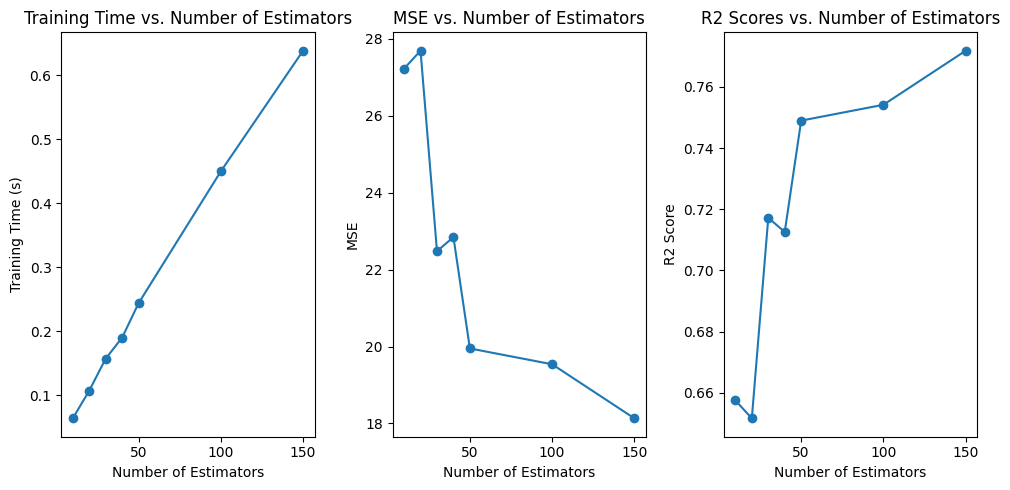

In [50]:
from sklearn.tree import DecisionTreeRegressor
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

import numpy as np

def weighted_median(values, weights):
    # Sort values and corresponding weights
    sorted_data = sorted(zip(values, weights), key=lambda x: x[0])
    
    # Calculate the cumulative sum of weights
    cumulative_weights = np.cumsum([w for _, w in sorted_data])
    
    # Find the index of the middle element
    index = np.searchsorted(cumulative_weights, 0.5 * cumulative_weights[-1])
    
    # Return the corresponding value
    return sorted_data[index][0]

# Source: https://dafriedman97.github.io/mlbook/content/c6/s2/boosting.html#:~:text=AdaBoost.R2%20Algorithm,-Initialize%20the%20weights&text=Draw%20a%20sample%20of%20size,%2C2%2C%E2%80%A6%2CN.

class AdaBoostR2:
    
    def fit(self, X_train, y_train, T = 100, stub_depth = 1, random_state = None):
        
        self.y_train = y_train
        self.X_train = X_train
        self.T = T
        self.stub_depth = stub_depth
        self.N, self.D = X_train.shape
        self.weights = np.repeat(1/self.N, self.N)
        np.random.seed(random_state)
        
        self.trees = []    
        self.fitted_values = np.empty((self.N, self.T))
        self.betas = []
        for t in range(self.T):
            
            ## Draw sample, fit tree, get predictions
            bootstrap_indices = np.random.choice(np.arange(self.N), size = self.N, replace = True, p = self.weights)
            self.y_train = np.ravel(self.y_train)
            bootstrap_X = self.X_train[bootstrap_indices]
            bootstrap_y = self.y_train[bootstrap_indices]
            tree = DecisionTreeRegressor(max_depth = stub_depth)
            tree.fit(bootstrap_X, bootstrap_y)
            self.trees.append(tree)
            yhat = tree.predict(X_train)
            self.fitted_values[:,t] = yhat
            
            ## Calculate observation errors
            abs_errors_t = np.abs(self.y_train - yhat)
            D_t = np.max(abs_errors_t)
            L_ts = abs_errors_t/D_t
            
            ## Calculate model error (and possibly break)
            Lbar_t = np.sum(self.weights*L_ts)
            if Lbar_t >= 0.5:
                self.T = t - 1
                self.fitted_values = self.fitted_values[:,:t-1]
                self.trees = self.trees[:t-1]
                break
            
            ## Calculate and record beta 
            beta_t = Lbar_t/(1 - Lbar_t)
            self.betas.append(beta_t)
            
            ## Reweight
            Z_t = np.sum(self.weights*beta_t**(1-L_ts))
            self.weights *= beta_t**(1-L_ts)/Z_t
            
        ## Get median 
        self.model_weights = np.log(1/np.array(self.betas))
        self.y_train_hat = np.array([weighted_median(self.fitted_values[n], self.model_weights) for n in range(self.N)])
        
    def predict(self, X_test):
        N_test = len(X_test)
        fitted_values = np.empty((N_test, self.T))
        for t, tree in enumerate(self.trees):
            fitted_values[:,t] = tree.predict(X_test)
        return np.array([weighted_median(fitted_values[n], self.model_weights) for n in range(N_test)]) 


X_train, X_test, y_train, y_test = X_train_regression, X_test_regression, y_train_regression, y_test_regression
booster = AdaBoostR2()
booster.fit(X_train, y_train, T = 50, stub_depth = 4, random_state = 123)

# Make predictions on test set
# predictions = booster.predict(X_test)

predicted_values = booster.predict(X_test)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, predicted_values)

# Print the result
print(f'Mean Squared Error: {mse}')

# Varying the number of estimators
estimator_range = [10, 20, 30, 40, 50, 100, 150]
training_times = []
accuracies = []
mses = []
r2scores = []

for n_estimators in estimator_range:
    start_time = time.time()
    
    booster = AdaBoostR2()
    booster.fit(X_train, y_train, T = n_estimators, stub_depth = 4, random_state = 123)
    predictions = booster.predict(X_test)  

    end_time = time.time()
    elapsed_time = end_time - start_time
    training_times.append(elapsed_time)

    # Calculate Mean Squared Error
    mse = mean_squared_error(y_test, predictions)
    mses.append(mse)
    print(f'Mean Squared Error: {mse}')
    
    # Calculate R2 score
    r2 = r2_score(y_test, predictions)
    print(f'R2 Score: {r2}')
    r2scores.append(r2)

# Plot training times and R2 Scores
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.plot(estimator_range, training_times, marker='o')
plt.title('Training Time vs. Number of Estimators')
plt.xlabel('Number of Estimators')
plt.ylabel('Training Time (s)')

plt.subplot(1, 3, 2)
plt.plot(estimator_range, mses, marker='o')
plt.title('MSE vs. Number of Estimators')
plt.xlabel('Number of Estimators')
plt.ylabel('MSE')

plt.subplot(1, 3, 3)
plt.plot(estimator_range, r2scores, marker='o')
plt.title('R2 Scores vs. Number of Estimators')
plt.xlabel('Number of Estimators')
plt.ylabel('R2 Score')

plt.tight_layout()
plt.show()


## Gradient Boosted Decision Trees

### Classification

Accuracy =  0.7161572052401747


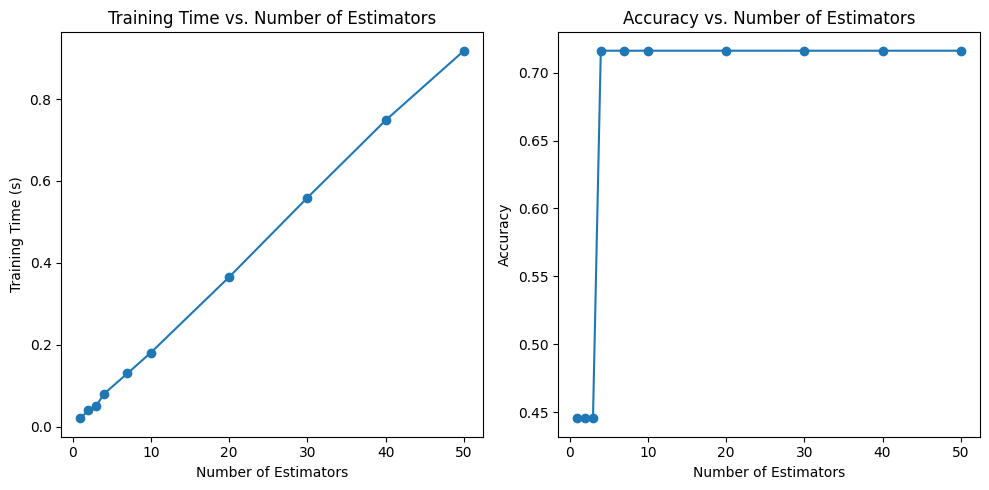

In [51]:

# Fit function was inspired from ChatGPT

class GradientBoostClassifier:
    def __init__(self, learning_rate, n_estimators):
        self.learning_rate = learning_rate
        self.n_estimators = n_estimators
        self.initial_log_odds = None
        self.log_odds = None
        self.predicted_prob = None
        self.models = []

    def fit(self, x_train, y_train):
        ones_value = np.sum(y_train == 1)
        zeros_value = np.sum(y_train == 0)
        self.log_odds = np.log(ones_value/zeros_value)
        self.predicted_prob = ones_value/y_train.shape[0]
        self.initial_log_odds = self.log_odds

        for _ in range(self.n_estimators):
            residuals = y_train-self.predicted_prob
            tree = DecisionTreeClassifier(random_state=42)
            label_encoder = LabelEncoder()
            tree.fit(x_train, label_encoder.fit_transform(residuals))
            epsilon = 1e-5                  
            outputs_leaf = np.sum(tree.predict(x_train)) / np.sum(self.predicted_prob * (1-self.predicted_prob)+epsilon)
            self.log_odds = self.log_odds + self.learning_rate * outputs_leaf
            self.predicted_prob = 1 / (1+np.exp(-self.log_odds))
            self.models.append(tree)
        return


    def predict(self, x_test):
        output = self.initial_log_odds + self.learning_rate * np.sum([tree.predict(x_test) for tree in self.models], axis=0)
        return np.where(output >= 0.5, 1, 0)


X_train, X_test, y_train, y_test = X_train_classification, X_test_classification, y_train_classification, y_test_classification
y_train = np.where(y_train > 5, 1, 0)
y_test = np.where(y_test > 5, 1, 0)

# Example Use
gb_classifier = GradientBoostClassifier(learning_rate=0.1, n_estimators=100)
gb_classifier.fit(X_train, y_train)
predictions = gb_classifier.predict(X_test)
print("Accuracy = ", accuracy_score(y_test, predictions))

# Varyingthe number of estimators
estimator_range = [1, 2, 3, 4, 7, 10, 20, 30, 40, 50]
training_times = []
accuracies = []

for n_estimators in estimator_range:
    start_time = time.time()

    gb_classifier = GradientBoostClassifier(learning_rate=0.1, n_estimators=n_estimators)
    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(y_train)
    gb_classifier.fit(X_train, y_train)
    predictions = gb_classifier.predict(X_test)

    end_time = time.time()
    elapsed_time = end_time - start_time
    accuracy = np.sum(label_encoder.fit_transform(predictions) == y_test) / len(y_test)

    training_times.append(elapsed_time)
    accuracies.append(accuracy)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(estimator_range, training_times, marker='o')
plt.title('Training Time vs. Number of Estimators')
plt.xlabel('Number of Estimators')
plt.ylabel('Training Time (s)')

plt.subplot(1, 2, 2)
plt.plot(estimator_range, accuracies, marker='o')
plt.title('Accuracy vs. Number of Estimators')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()


### Regression

Mean Squared Error: 72.82316662662555
R2 Score: 0.08374747875415589
Mean Squared Error: 63.95673891156529
R2 Score: 0.19530382990845652
Mean Squared Error: 56.80154875988908
R2 Score: 0.2853295912170808
Mean Squared Error: 50.47193299850704
R2 Score: 0.3649680726033504
Mean Squared Error: 45.339255580019476
R2 Score: 0.42954681647400483
Mean Squared Error: 28.185969933483033
R2 Score: 0.6453674399010396
Mean Squared Error: 20.062574443383625
R2 Score: 0.7475750469533725


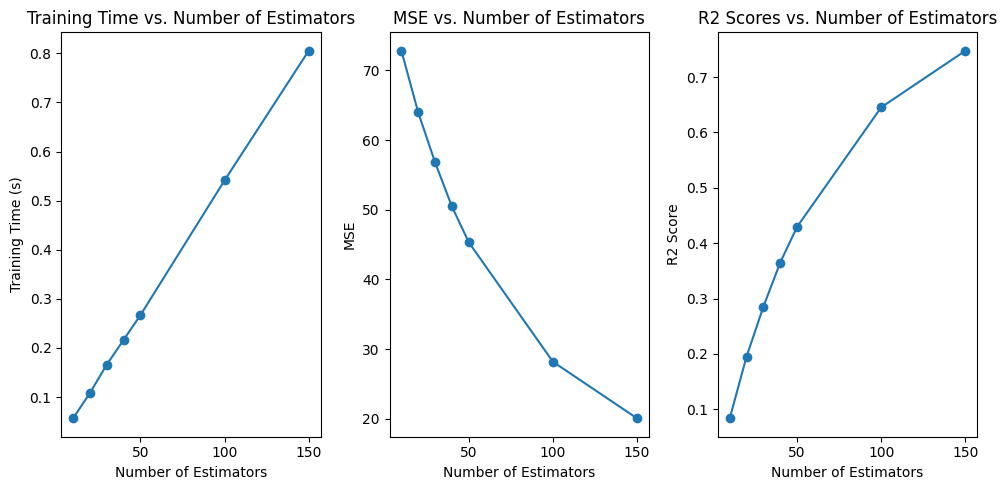

In [52]:
X_train, X_test, y_train, y_test = X_train_regression, X_test_regression, y_train_regression, y_test_regression

class GradientBoostingRegressor:
    def __init__(self, n_estimators=50, learning_rate=0.01):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.models = []
        self.initial_mean = None 
        
    def fit(self, X, y):
        n_samples, _ = X.shape
        predictions = np.full(y.shape, np.mean(y))
        self.initial_mean = np.mean(y)
        
        for _ in range(self.n_estimators):
            residuals = y - predictions
            tree = DecisionTreeRegressor(max_depth=3)
            tree.fit(X, residuals)
            update = self.learning_rate * tree.predict(X)
            predictions += update
            self.models.append(tree)

    def predict(self, X):
        return self.initial_mean + self.learning_rate * np.sum([model.predict(X) for model in self.models], axis=0)

# Varying the number of estimators
estimator_range = [10, 20, 30, 40, 50, 100, 150]
training_times = []
mses = []
r2scores = []

for n_estimators in estimator_range:
    start_time = time.time()

    gb_regressor = GradientBoostingRegressor(n_estimators=n_estimators)
    gb_regressor.fit(X_train, y_train)
    predictions = gb_regressor.predict(X_test)    

    end_time = time.time()
    elapsed_time = end_time - start_time
    training_times.append(elapsed_time)

    # Calculate Mean Squared Error
    mse = mean_squared_error(y_test, predictions)
    mses.append(mse)
    print(f'Mean Squared Error: {mse}')
    
    # Calculate R2 score
    r2 = r2_score(y_test, predictions)
    print(f'R2 Score: {r2}')
    r2scores.append(r2)

# Plot training times and R2 Scores
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.plot(estimator_range, training_times, marker='o')
plt.title('Training Time vs. Number of Estimators')
plt.xlabel('Number of Estimators')
plt.ylabel('Training Time (s)')

plt.subplot(1, 3, 2)
plt.plot(estimator_range, mses, marker='o')
plt.title('MSE vs. Number of Estimators')
plt.xlabel('Number of Estimators')
plt.ylabel('MSE')

plt.subplot(1, 3, 3)
plt.plot(estimator_range, r2scores, marker='o')
plt.title('R2 Scores vs. Number of Estimators')
plt.xlabel('Number of Estimators')
plt.ylabel('R2 Score')

plt.tight_layout()
plt.show()
